Age                         0.0
Gender                      0.0
Air Pollution               0.0
Alcohol use                 0.0
Dust Allergy                0.0
OccuPational Hazards        0.0
Genetic Risk                0.0
chronic Lung Disease        0.0
Balanced Diet               0.0
Obesity                     0.0
Smoking                     0.0
Passive Smoker              0.0
Chest Pain                  0.0
Coughing of Blood           0.0
Fatigue                     0.0
Weight Loss                 0.0
Shortness of Breath         0.0
Wheezing                    0.0
Swallowing Difficulty       0.0
Clubbing of Finger Nails    0.0
Frequent Cold               0.0
Dry Cough                   0.0
Snoring                     0.0
Level                       0.0
dtype: float64
       Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
index                                                          
0       33       1              2            4             5   
1       17       1       

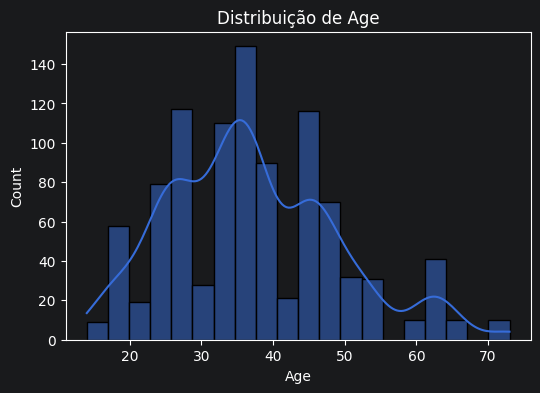

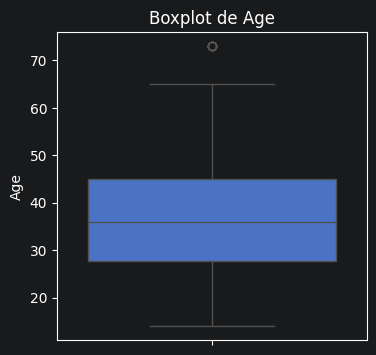

Média: 37.174
Mediana: 36.0
Moda: 35
Skewness (Assimetria): 0.5502689405577516
Outliers encontrados:
       Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
index                                                          
15      73       1              5            6             6   
126     73       1              5            6             6   
237     73       1              5            6             6   
348     73       1              5            6             6   
459     73       1              5            6             6   
570     73       1              5            6             6   
681     73       1              5            6             6   
792     73       1              5            6             6   
889     73       1              5            6             6   
903     73       1              5            6             6   

       OccuPational Hazards  Genetic Risk  chronic Lung Disease  \
index                                                          

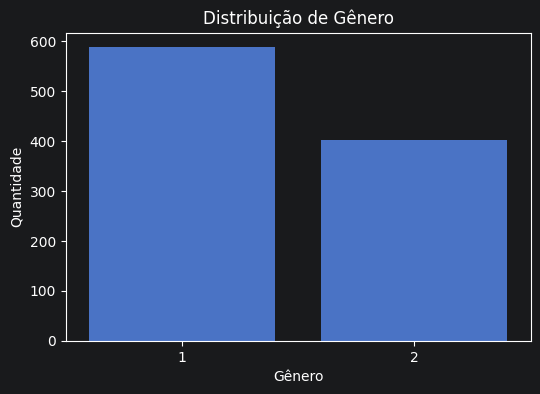

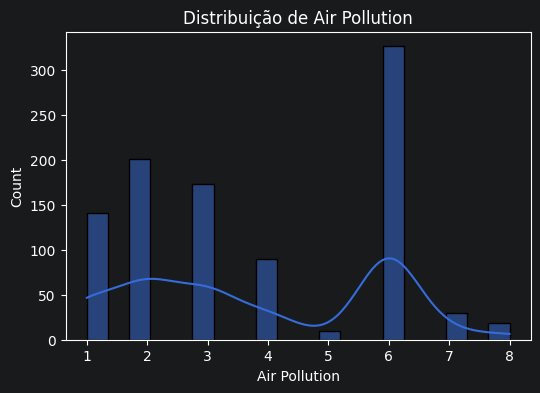

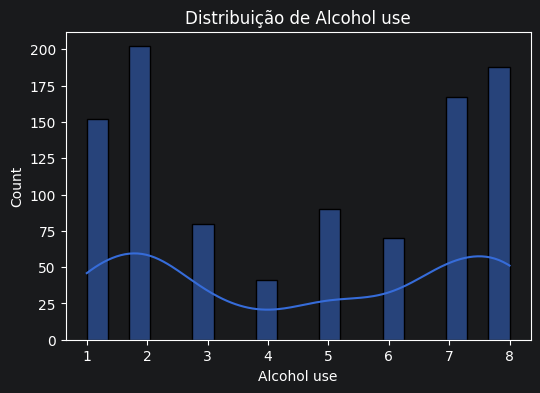

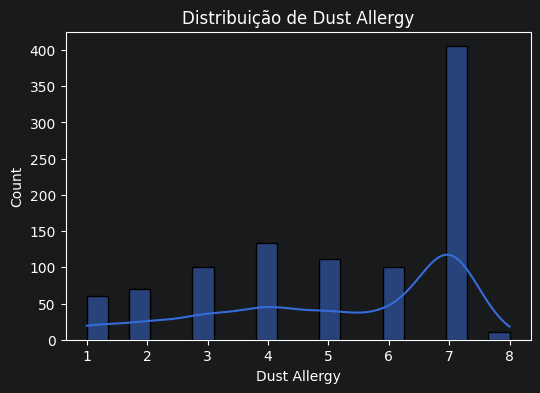

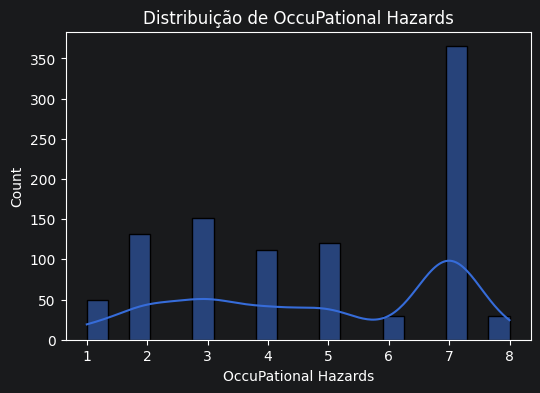

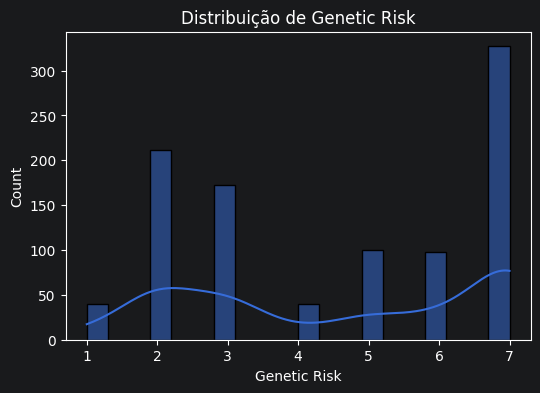

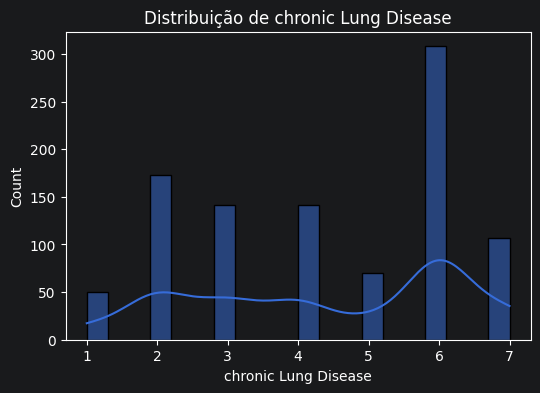

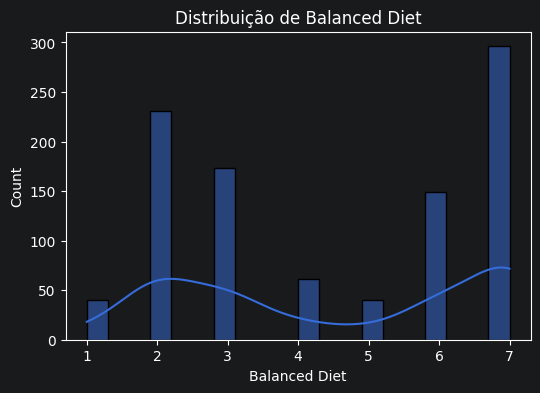

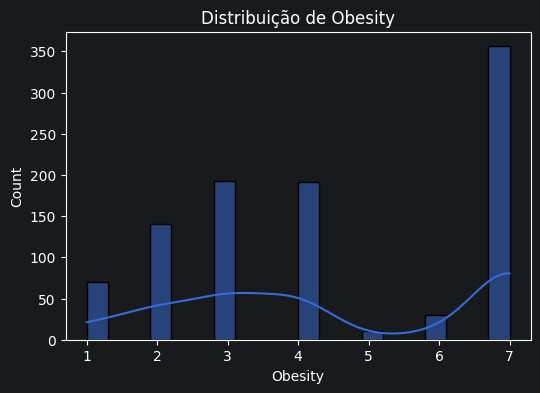

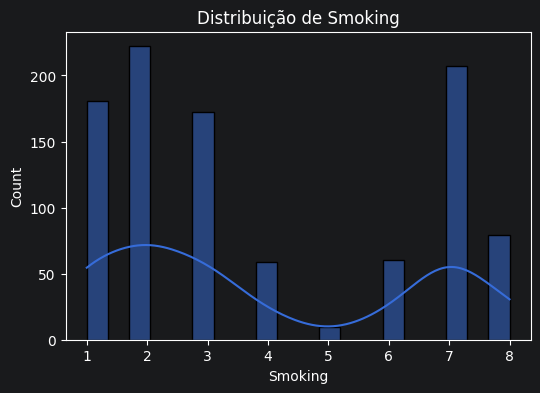

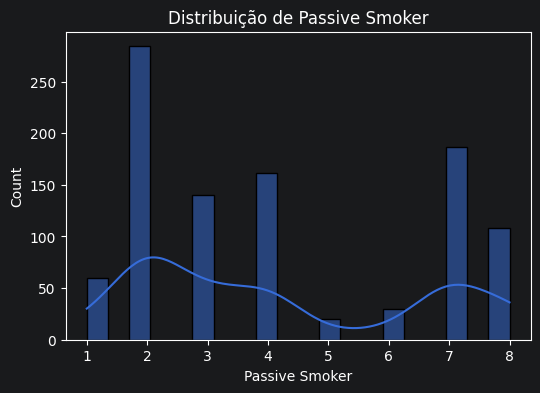

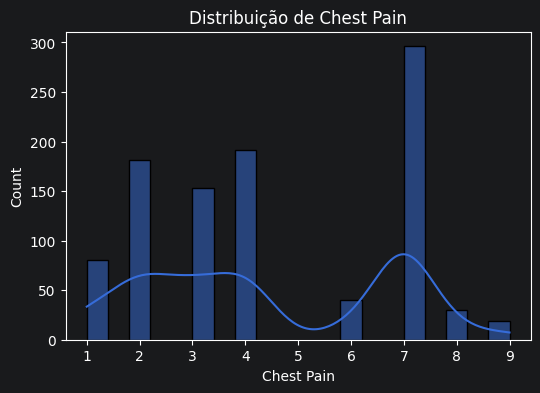

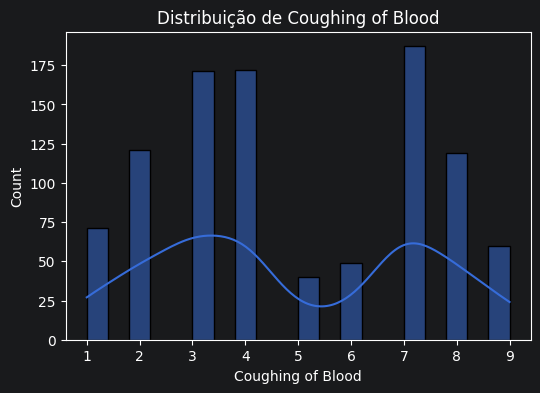

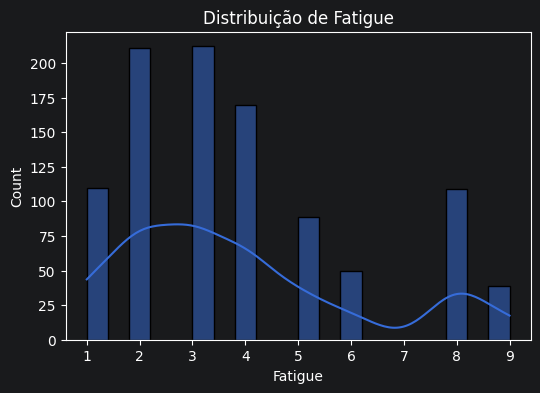

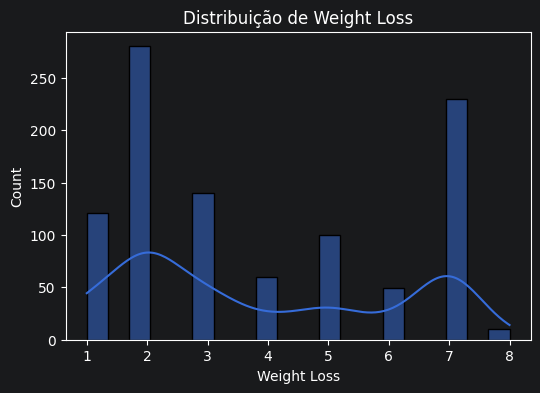

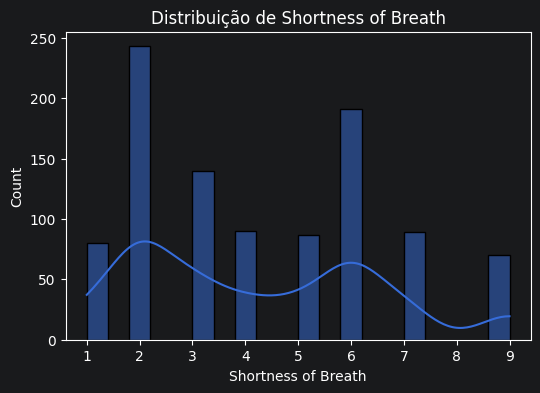

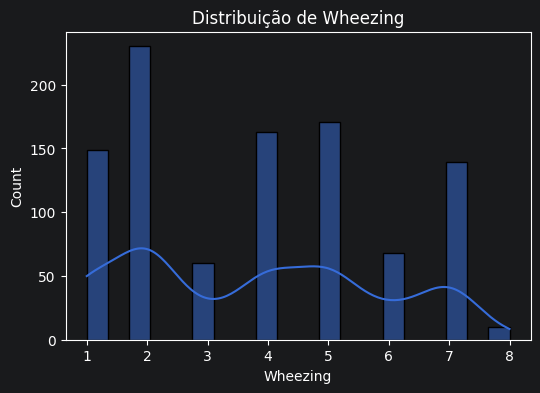

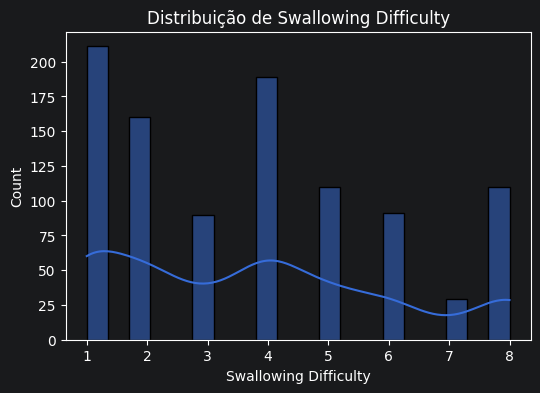

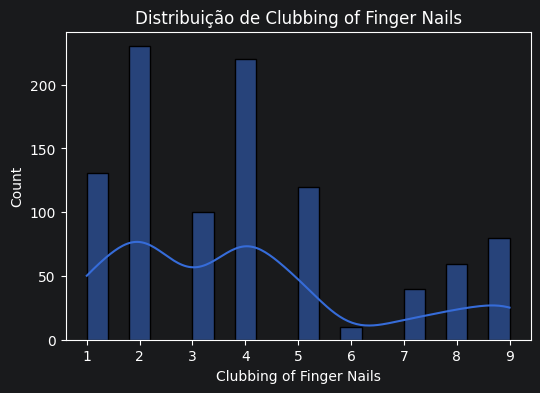

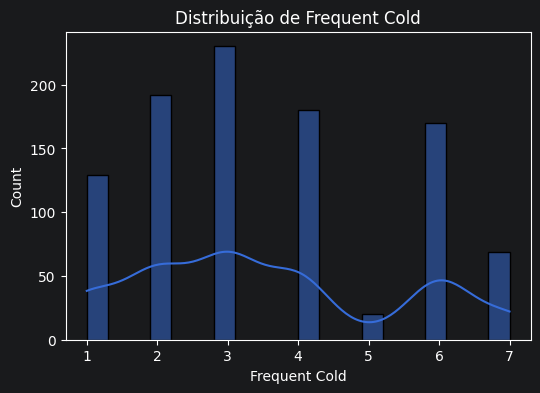

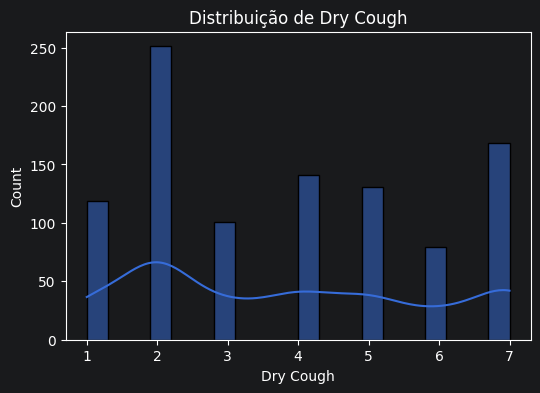

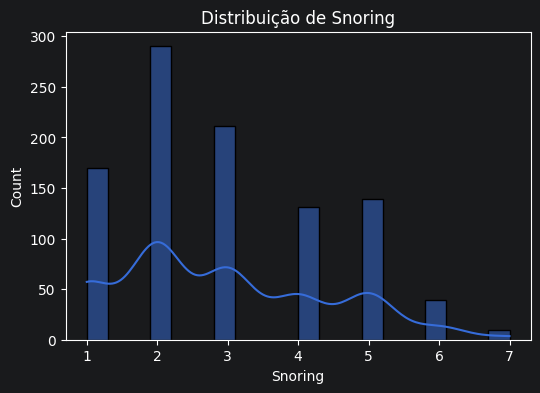

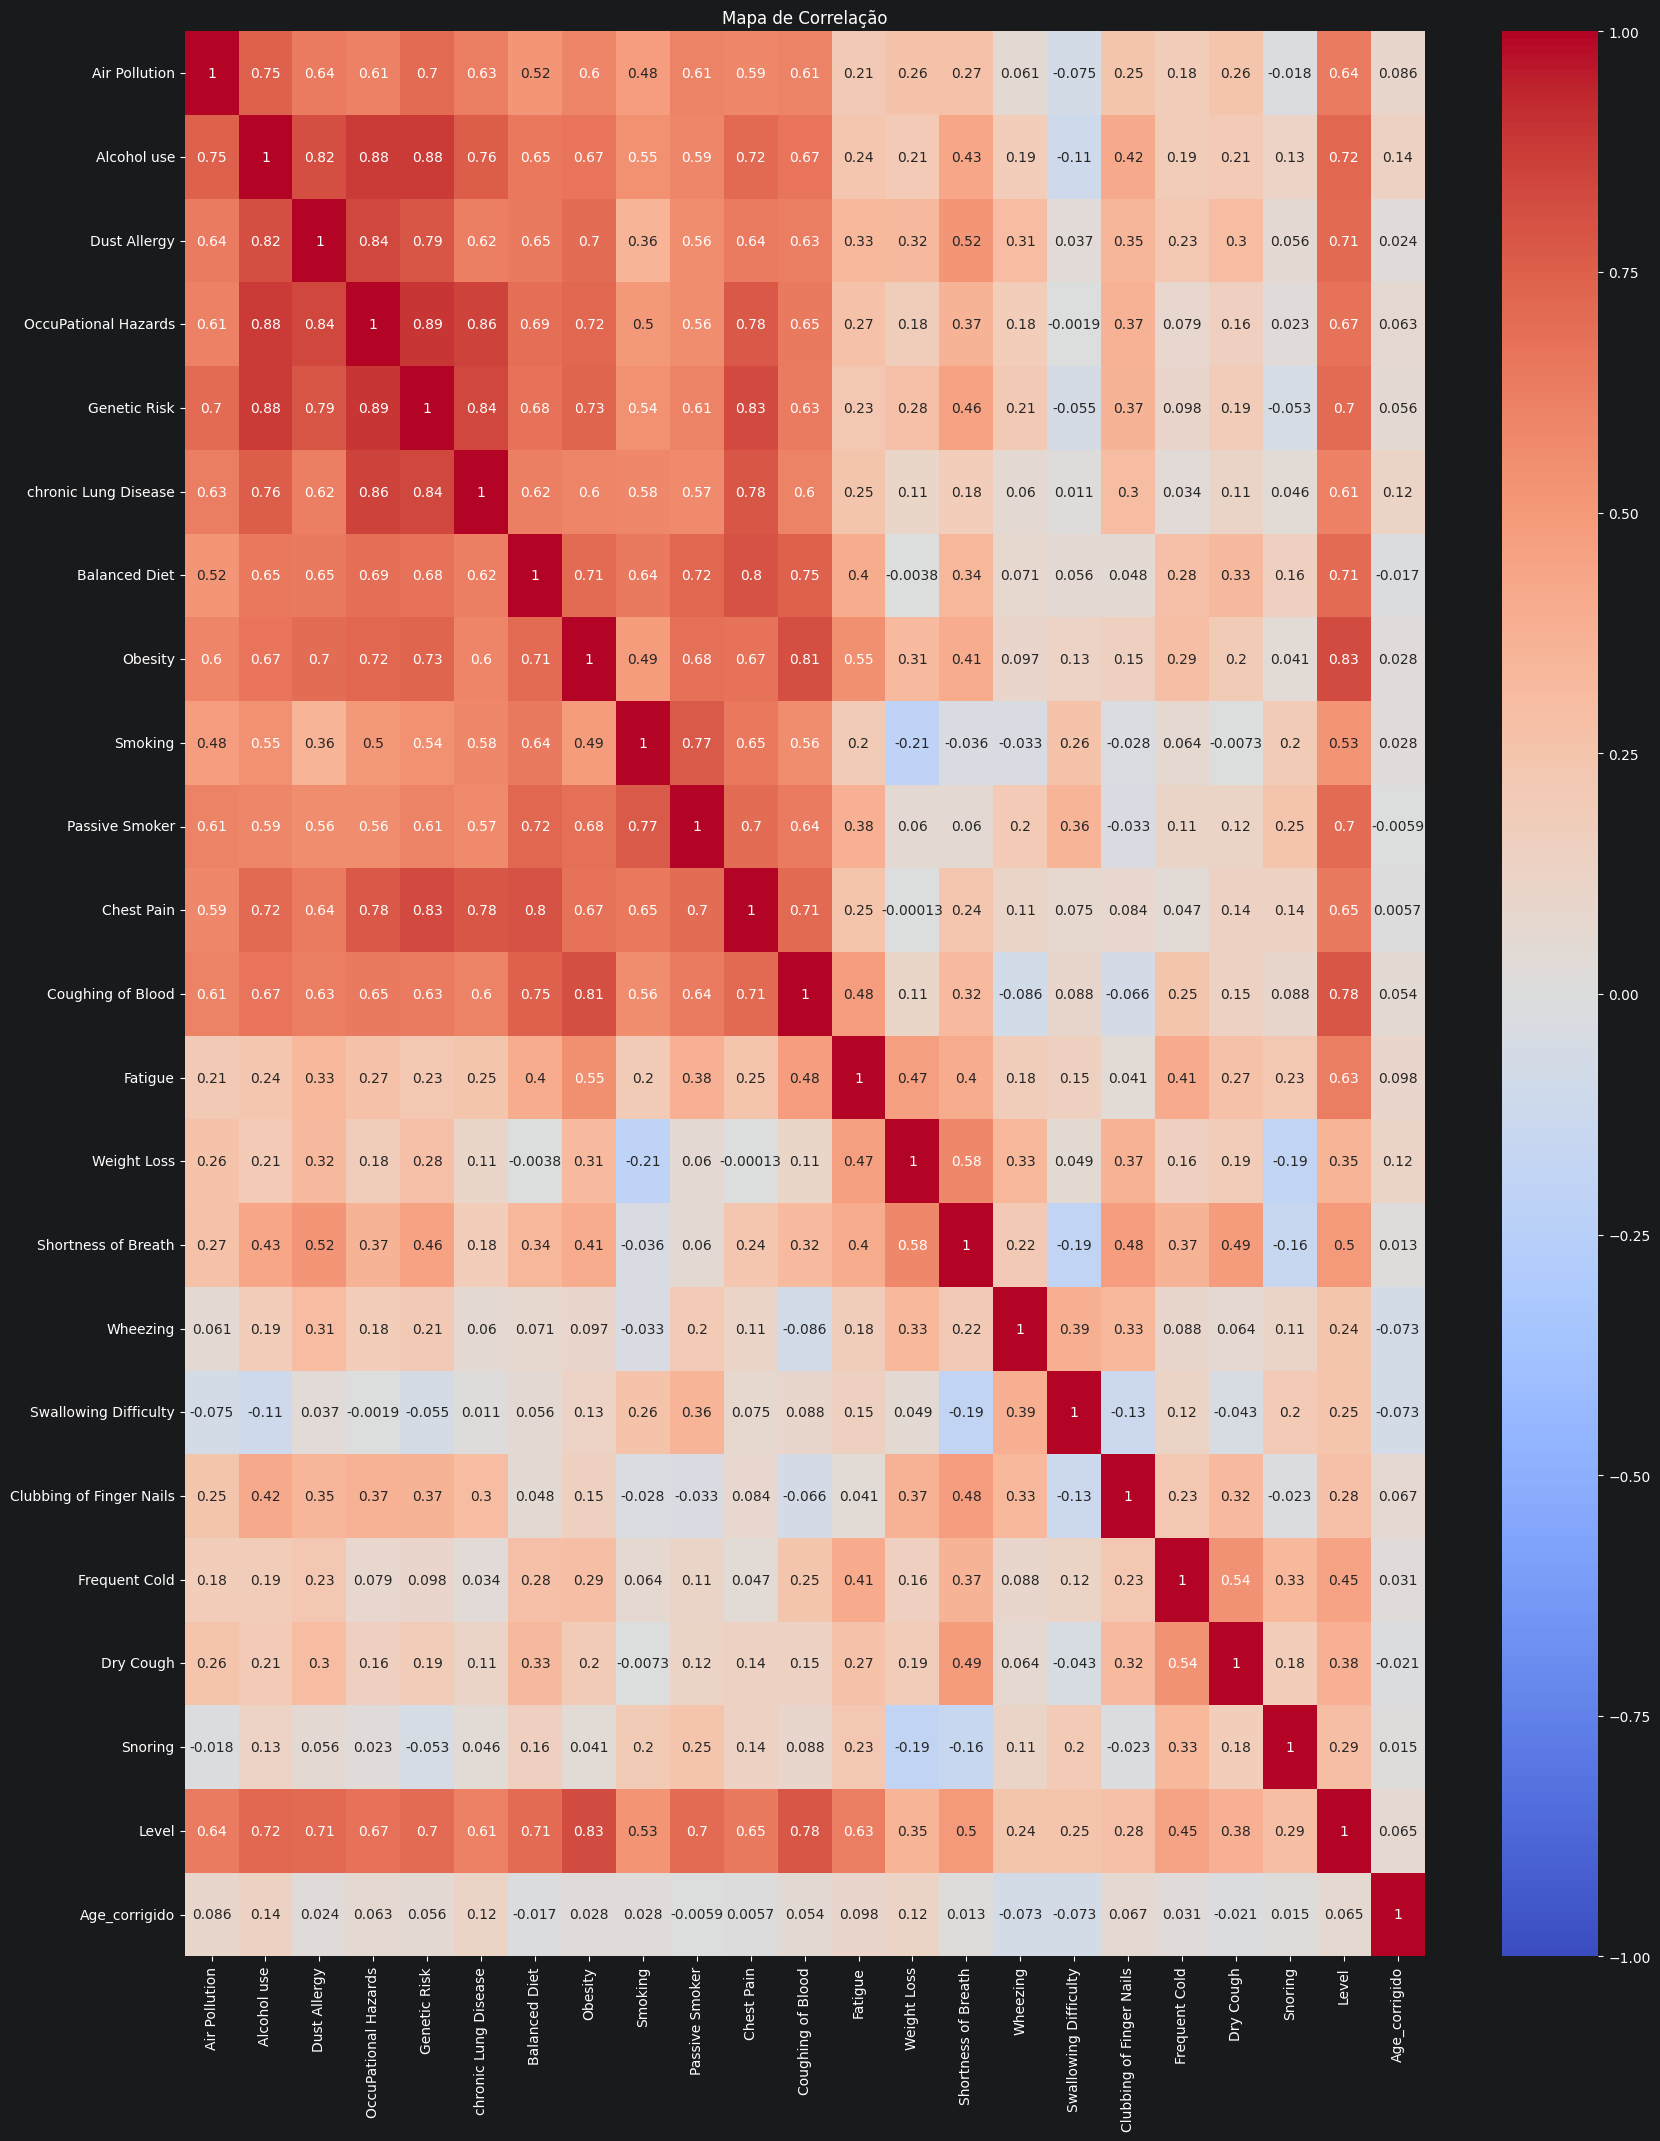

Acurácia inicial do modelo: 1.00


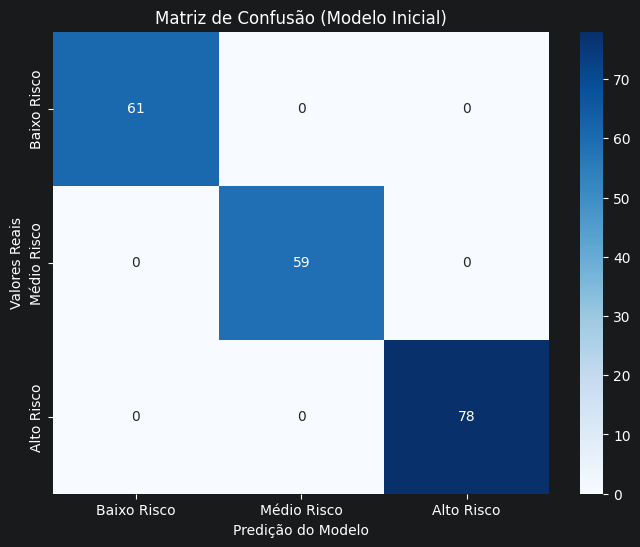


Melhores parâmetros encontrados:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Acurácia do modelo com hiperparâmetros ajustados: 1.00


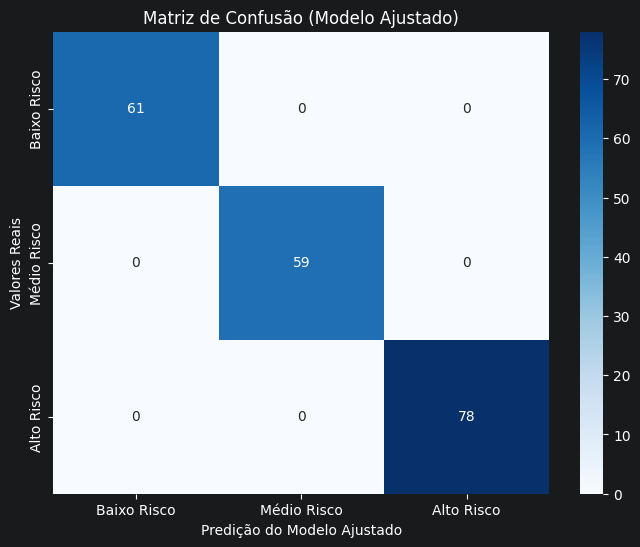

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        59
           2       1.00      1.00      1.00        78

    accuracy                           1.00       198
   macro avg       1.00      1.00      1.00       198
weighted avg       1.00      1.00      1.00       198

Acurácia por fold: [1. 1. 1. 1. 1.]
Média da acurácia: 1.0

Insira as seguintes informações para prever o risco de câncer:


KeyboardInterrupt: Interrupted by user

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from scipy.stats import skew
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score

# 1. Carregamento e Tratamento dos Dados
# Carrega o arquivo direto do caminho do seu computador
df_1 = pd.read_csv('../cancer/Dataset(1).csv', index_col='index')
df_1.drop(['Patient Id'], axis=1, inplace=True)

# Exclusão dos valores nulos específicos
df = df_1[df_1.index != 1000].copy()

## Transformação do level para categoria numérica
mapa = {'Low': 0, 'Medium': 1, 'High': 2}
df['Level'] = df['Level'].map(mapa)

print(df.isnull().mean() * 100)
print(df.head())
df.info()
print(df.describe())

## Analise univariada da coluna age
print(df['Age'].describe())

# Histograma
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], kde=True, bins=20)
plt.title("Distribuição de Age")
plt.show()

# Boxplot para outliers
plt.figure(figsize=(4, 4))
sns.boxplot(y=df['Age'])
plt.title("Boxplot de Age")
plt.show()

# Media, moda, mediana e skewness da coluna
media = df['Age'].mean()
mediana = df['Age'].median()
moda = df['Age'].mode()[0]
assimetria = skew(df['Age'])
print(f"Média: {media}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")
print(f"Skewness (Assimetria): {assimetria}")



# Visualização dos outliers encontrados em age
Q3 = df['Age'].quantile(0.75)
Q1 = df['Age'].quantile(0.25)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df[(df['Age'] < limite_inferior) | (df['Age'] > limite_superior)]
print(f'Outliers encontrados:\n{outliers}')

# Outliers influenciam a skewness do gráfico?
idades_sem_out = df[df['Age'] != 73]
media2 = idades_sem_out.mean()
mediana2 = idades_sem_out.median()
moda2 = idades_sem_out['Age'].mode()
assimetria2 = skew(idades_sem_out['Age'])
print(f"Média: {media2['Age']}")
print(f"Mediana: {mediana2['Age']}")
print(f"Moda: {moda2}")
print(f"Skewness (Assimetria): {assimetria2}")

## Remoção dos outliers em age
df['Age_corrigido'] = np.where((df['Age'] == 73), np.nan, df['Age'])
# Remoção de nulos em age_corrigido
df = df.dropna(subset=['Age_corrigido'])
# Apagando antiga coluna age
df.drop(['Age'], axis=1, inplace=True)

# Gráfico de barras da distribuição de homem e mulher
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df)
plt.title('Distribuição de Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.show()

## Demais variaveis
colunas_escala = ['Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk',
                  'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker',
                  'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath',
                  'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold',
                  'Dry Cough', 'Snoring']

for coluna in colunas_escala:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[coluna], kde=True, bins=20)
    plt.title(f"Distribuição de {coluna}")
    plt.show()

# Analise multivariada e matriz de correlação (CORRIGIDO: Fora do laço 'for')
df_novo = df.drop(columns=['Gender'])
corr = df_novo.corr(method='pearson')

plt.figure(figsize=(20, 25))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Mapa de Correlação")
plt.show()

# 2. Treinamento do Modelo Preditivo
X = df.drop(columns=["Level"])
y = df["Level"]

# Divide os dados em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Treina o modelo inicial
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_treino, y_treino)

# Avalia o modelo inicial
y_predicao = modelo.predict(X_teste)
acuracia = accuracy_score(y_teste, y_predicao)
print(f"Acurácia inicial do modelo: {acuracia:.2f}")

# Matriz de Confusão Inicial
matriz_confusao = confusion_matrix(y_teste, y_predicao)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baixo Risco', 'Médio Risco', 'Alto Risco'],
            yticklabels=['Baixo Risco', 'Médio Risco', 'Alto Risco'])
plt.xlabel('Predição do Modelo')
plt.ylabel('Valores Reais')
plt.title('Matriz de Confusão (Modelo Inicial)')
plt.show()

# 3. Ajuste de Hiperparâmetros
parametros = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=modelo, param_grid=parametros, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_treino, y_treino)

print("\nMelhores parâmetros encontrados:")
print(grid_search.best_params_)

melhor_modelo = grid_search.best_estimator_

# Avalia o modelo ajustado
y_predicao_ajustada = melhor_modelo.predict(X_teste)
acuracia_ajustada = accuracy_score(y_teste, y_predicao_ajustada)
print(f"Acurácia do modelo com hiperparâmetros ajustados: {acuracia_ajustada:.2f}")

# Matriz de Confusão Ajustada
matriz_confusao_ajustada = confusion_matrix(y_teste, y_predicao_ajustada)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao_ajustada, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baixo Risco', 'Médio Risco', 'Alto Risco'],
            yticklabels=['Baixo Risco', 'Médio Risco', 'Alto Risco'])
plt.xlabel('Predição do Modelo Ajustado')
plt.ylabel('Valores Reais')
plt.title('Matriz de Confusão (Modelo Ajustado)')
plt.show()

print(classification_report(y_teste, y_predicao))

# Validação Cruzada
scores = cross_val_score(melhor_modelo, X, y, cv=5, scoring='accuracy')
print("Acurácia por fold:", scores)
print("Média da acurácia:", np.mean(scores))

# 4. Interface de Predição para o Usuário
user_data = {}
feature_names = [col for col in df.columns if col != 'Level']

print("\nInsira as seguintes informações para prever o risco de câncer:")

for feature in feature_names:
    while feature not in user_data:
        try:
            if feature == 'Gender':
                value = int(input(f"Digite o valor para {feature} (1 para Homem, 2 para Mulher): "))
                if value not in [1, 2]:
                    print("Entrada inválida para Gênero. Digite 1 para Homem ou 2 para Mulher.")
                    continue
            elif feature in colunas_escala:
                value = int(input(f"Digite o valor para {feature}: "))
            else:
                value = float(input(f"Digite o valor para {feature}: "))
            user_data[feature] = value
        except ValueError:
            print(f"Entrada inválida para {feature}. Por favor, digite um número.")

# Converte dados do usuário e garante a ordem correta das colunas
user_df = pd.DataFrame([user_data])
user_df = user_df[X_treino.columns]

# Predições finais
predicted_level_numeric = melhor_modelo.predict(user_df)
predicted_probabilities = melhor_modelo.predict_proba(user_df)

risk_levels = {0: 'Baixo Risco', 1: 'Médio Risco', 2: 'Alto Risco'}
predicted_level = risk_levels[predicted_level_numeric[0]]

print("\n--- Resultado da Predição ---")
print(f"Nível de risco previsto: {predicted_level}")
print("Probabilidades por classe:")
for i, level in risk_levels.items():
    print(f"- {level}: {predicted_probabilities[0][i] * 100:.2f}%")